# 04 - Funnel and Marketplace Analysis

## Objective

This notebook turns the cleaned captain-level data into the main analyses required for the take-home:

- **A1–A2:** signup → approval funnel and the largest actionable leak
- **A3:** evaluation of `CAMP_WA_002`
- **B1–B2:** airport demand–supply pressure and post-airport-trip behavior

The analysis uses the cleaned captain-level dataset from Notebook 03 and the raw airport, document-event, and nudge datasets where event-level detail is needed.

**Cohorting rule:** captains who signed up within 14 days of the June 30, 2026 extraction cutoff are excluded from the primary A2O funnel because they may not have had enough time to complete onboarding. These captains remain in the underlying data and are not treated as failures.

## 1. Load the Analysis Datasets

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [2]:
captain_base = pd.read_csv(
    "../data/captain_base.csv",
    parse_dates=["signup_ts", "decision_ts", "first_order_ts"]
)

doc_events = pd.read_csv(
    "../data/doc_events.csv",
    parse_dates=["event_ts"]
)

airport_hourly = pd.read_csv(
    "../data/airport_hourly.csv",
    parse_dates=["hour_ts"]
)

airport_trips = pd.read_csv(
    "../data/airport_trips.csv",
    parse_dates=["request_ts"]
)

nudges = pd.read_csv(
    "../data/nudges.csv",
    parse_dates=["sent_ts"]
)

print(f"Captain-level rows: {len(captain_base):,}")
print(f"Document events: {len(doc_events):,}")
print(f"Airport hourly rows: {len(airport_hourly):,}")
print(f"Airport trips: {len(airport_trips):,}")
print(f"Nudge records: {len(nudges):,}")

Captain-level rows: 25,000
Document events: 186,282
Airport hourly rows: 10,248
Airport trips: 60,000
Nudge records: 16,314


## 2. Define the primary funnel cohort

The primary A2O funnel uses the `eligible_for_funnel` flag created in Notebook 03. This keeps the denominator consistent across all stages.

In [3]:
funnel = captain_base[captain_base["eligible_for_funnel"]].copy()

In [4]:
print("Total captains:", f"{len(captain_base):,}")
print("Funnel-eligible signups:", f"{len(funnel):,}")
print("Excluded as potentially censored:", f"{len(captain_base) - len(funnel):,}")

Total captains: 25,000
Funnel-eligible signups: 22,757
Excluded as potentially censored: 2,243


## 3. Build cumulative funnel stages

The stages follow the required document order: **DL → RC → Aadhaar → Permit (Auto/Cab only) → Fitness → Insurance → Approval**. A captain only reaches a stage if all preceding required stages have been cleared.

In [5]:
funnel["stage_dl"] = funnel["DL_cleared"]

In [6]:
funnel["stage_rc"] = (
    funnel["stage_dl"]
    & funnel["RC_cleared"]
)

In [7]:
funnel["stage_aadhaar"] = (
    funnel["stage_rc"]
    & funnel["AADHAAR_cleared"]
)

In [8]:
permit_required = funnel["vehicle_type"].isin(["Auto", "Cab"])

In [9]:
funnel["stage_permit"] = (
    funnel["stage_aadhaar"]
    & (
        ~permit_required
        | funnel["PERMIT_cleared"]
    )
)

In [10]:
funnel["stage_fitness"] = (
    funnel["stage_permit"]
    & funnel["FITNESS_cleared"]
)

In [11]:
funnel["stage_insurance"] = (
    funnel["stage_fitness"]
    & funnel["INSURANCE_cleared"]
)

In [12]:
funnel["stage_approved"] = (
    funnel["final_status"] == "approved"
)

In [13]:
stage_columns = [
    "stage_dl",
    "stage_rc",
    "stage_aadhaar",
    "stage_permit",
    "stage_fitness",
    "stage_insurance",
    "stage_approved",
]

In [14]:
stage_counts = funnel[stage_columns].sum()
display(stage_counts.to_frame("captains"))

,captains
stage_dl,20136
stage_rc,14647
stage_aadhaar,13093
stage_permit,10439
stage_fitness,7752
stage_insurance,4412
stage_approved,3998


In [15]:
print(f"Permit required (Auto/Cab): {permit_required.sum():,}")
print(f"Permit not required (ERickshaw): {(~permit_required).sum():,}")

Permit required (Auto/Cab): 18,416
Permit not required (ERickshaw): 4,341


## 4. A1 — Signup → Approval funnel

For each stage, we show the number of captains reaching it, the absolute loss from the previous stage, the stage-to-stage conversion, and cumulative conversion from signup.

In [16]:
funnel_table = pd.DataFrame({
    "stage": [
        "Signup",
        "DL",
        "RC",
        "Aadhaar",
        "Permit",
        "Fitness",
        "Insurance",
        "Approved",
    ],
    "captains": [
        len(funnel),
        funnel["stage_dl"].sum(),
        funnel["stage_rc"].sum(),
        funnel["stage_aadhaar"].sum(),
        funnel["stage_permit"].sum(),
        funnel["stage_fitness"].sum(),
        funnel["stage_insurance"].sum(),
        funnel["stage_approved"].sum(),
    ],
})

In [17]:
funnel_table["volume_lost"] = (
    funnel_table["captains"].shift(1) - funnel_table["captains"]
).fillna(0).astype(int)

In [18]:
funnel_table["stage_conversion_pct"] = np.where(
    funnel_table["captains"].shift(1).notna(),
    funnel_table["captains"] / funnel_table["captains"].shift(1) * 100,
    100,
)

In [19]:
funnel_table["cumulative_conversion_pct"] = (
    funnel_table["captains"] / len(funnel) * 100
)

In [20]:
display(
    funnel_table.style.format({
        "captains": "{:,.0f}",
        "volume_lost": "{:,.0f}",
        "stage_conversion_pct": "{:.1f}%",
        "cumulative_conversion_pct": "{:.1f}%",
    })
)

,stage,captains,volume_lost,stage_conversion_pct,cumulative_conversion_pct
0,Signup,"22,757",0,100.0%,100.0%
1,DL,"20,136","2,621",88.5%,88.5%
2,RC,"14,647","5,489",72.7%,64.4%
3,Aadhaar,"13,093","1,554",89.4%,57.5%
4,Permit,"10,439","2,654",79.7%,45.9%
5,Fitness,"7,752","2,687",74.3%,34.1%
6,Insurance,"4,412","3,340",56.9%,19.4%
7,Approved,"3,998",414,90.6%,17.6%


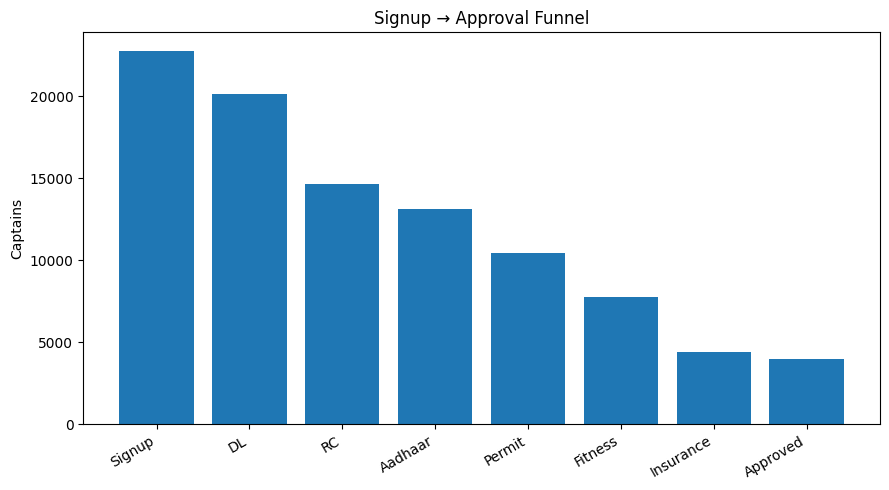

In [21]:
plt.figure(figsize=(9, 5))
plt.bar(funnel_table["stage"], funnel_table["captains"])
plt.ylabel("Captains")
plt.title("Signup → Approval Funnel")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 5. Where is the largest captain-level leak?

The absolute drop between consecutive cumulative stages identifies where the most captains are lost. This is different from document-event failure volume, which can contain multiple attempts from the same captain.

In [22]:
dropoff = funnel_table.iloc[1:].copy()
largest_drop = dropoff.loc[dropoff["volume_lost"].idxmax()]

In [23]:
print(
    f"Largest absolute drop: {largest_drop['stage']} "
    f"({largest_drop['volume_lost']:,} captains)"
)

Largest absolute drop: RC (5,489 captains)


In [24]:
display(
    dropoff[
        ["stage", "volume_lost", "stage_conversion_pct", "cumulative_conversion_pct"]
    ].sort_values("volume_lost", ascending=False)
)

,stage,volume_lost,stage_conversion_pct,cumulative_conversion_pct
2,RC,5489,72.740366,64.362614
6,Insurance,3340,56.914345,19.387441
5,Fitness,2687,74.259987,34.064244
4,Permit,2654,79.729627,45.871600
1,DL,2621,88.482665,88.482665
3,Aadhaar,1554,89.390319,57.533946
7,Approved,414,90.616500,17.568221


## 5.1 Verification failure reasons

Failure reasons are examined at the event level. Because one captain can have multiple attempts, these counts describe **verification friction**, not unique captains permanently lost.

In [25]:
failure_events = doc_events[
    doc_events["event_type"] == "verification_fail"
].copy()

In [26]:
failure_summary = (
    failure_events["failure_reason"]
    .value_counts(dropna=False)
    .rename_axis("failure_reason")
    .reset_index(name="failure_events")
)

In [27]:
failure_summary["failure_share_pct"] = (
    failure_summary["failure_events"]
    / failure_summary["failure_events"].sum()
    * 100
)

In [28]:
display(failure_summary)

,failure_reason,failure_events,failure_share_pct
0,image_blurred,4767,24.109852
1,ocr_low_confidence,3696,18.693101
2,name_mismatch,3173,16.047947
3,document_expired,2686,13.584867
4,details_not_legible,2171,10.980174
5,wrong_document_type,2083,10.535100
6,duplicate_document,1196,6.048958


## 5.2 Verification failures by document

In [29]:
failure_by_doc = (
    failure_events
    .groupby("doc_type")
    .size()
    .reset_index(name="failure_events")
)

In [30]:
failure_by_doc["failure_share_pct"] = (
    failure_by_doc["failure_events"]
    / failure_by_doc["failure_events"].sum()
    * 100
)

In [31]:
display(
    failure_by_doc.sort_values("failure_events", ascending=False)
)

,doc_type,failure_events,failure_share_pct
5,RC,8174,41.341291
1,DL,3408,17.236496
2,FITNESS,2693,13.620271
3,INSURANCE,2126,10.752579
4,PERMIT,1921,9.715760
0,AADHAAR,1450,7.333603


In [32]:
display(
    pd.crosstab(
        failure_events["doc_type"],
        failure_events["failure_reason"]
    )
)

failure_reason,details_not_legible,document_expired,duplicate_document,image_blurred,name_mismatch,ocr_low_confidence,wrong_document_type
doc_type,,,,,,,
AADHAAR,164,233,107,266,304,196,180
DL,428,531,239,624,693,497,396
FITNESS,281,301,150,750,386,574,251
INSURANCE,272,244,106,569,304,417,214
PERMIT,189,467,141,270,362,239,253
RC,837,910,453,2288,1124,1773,789


## 5.3 Segment the largest funnel leak

The RC stage is examined across city, vehicle, acquisition channel, and device tier. We report both the number lost and the drop-off rate among captains who reached DL, so large segments are not automatically mistaken for high-risk segments.

In [33]:
def stage_dropoff_by_segment(df, group_col, previous_stage, current_stage):
    grouped = (
        df.groupby(group_col)
        .agg(
            previous_stage=(previous_stage, "sum"),
            current_stage=(current_stage, "sum"),
        )
        .reset_index()
    )

    grouped["dropoff"] = (
        grouped["previous_stage"] - grouped["current_stage"]
    )

    grouped["dropoff_rate_pct"] = np.where(
        grouped["previous_stage"] > 0,
        grouped["dropoff"] / grouped["previous_stage"] * 100,
        np.nan,
    )

    return grouped.sort_values("dropoff", ascending=False)

In [34]:
rc_by_city = stage_dropoff_by_segment(
    funnel, "city", "stage_dl", "stage_rc"
)
rc_by_vehicle = stage_dropoff_by_segment(
    funnel, "vehicle_type", "stage_dl", "stage_rc"
)
rc_by_channel = stage_dropoff_by_segment(
    funnel, "acquisition_channel", "stage_dl", "stage_rc"
)
rc_by_device = stage_dropoff_by_segment(
    funnel, "device_tier", "stage_dl", "stage_rc"
)

In [35]:
display(rc_by_city)

,city,previous_stage,current_stage,dropoff,dropoff_rate_pct
2,Hyderabad,6151,4444,1707,27.751585
1,Delhi,5211,3810,1401,26.885435
0,Bangalore,4372,3167,1205,27.561757
3,Pune,4402,3226,1176,26.715129


In [36]:
display(rc_by_vehicle)

,vehicle_type,previous_stage,current_stage,dropoff,dropoff_rate_pct
0,Auto,9144,6667,2477,27.088801
1,Cab,7153,5169,1984,27.736614
2,ERickshaw,3839,2811,1028,26.777807


In [37]:
display(rc_by_channel)

,acquisition_channel,previous_stage,current_stage,dropoff,dropoff_rate_pct
2,organic_app,6670,4790,1880,28.185907
4,referral,4437,3159,1278,28.803245
0,fos_field,5239,4110,1129,21.549914
3,paid_digital,2656,1776,880,33.132530
1,gc_telecalling,1134,812,322,28.395062


In [38]:
display(rc_by_device)

,device_tier,previous_stage,current_stage,dropoff,dropoff_rate_pct
1,low,9279,6235,3044,32.805259
2,mid,7739,5929,1810,23.388035
0,high,3118,2483,635,20.365619


## 5.4 Attempt and recovery analysis

A failed document attempt does not necessarily mean permanent loss. For each captain-document pair, we identify whether a failure occurred and whether that document was eventually cleared in a later attempt.

In [39]:
doc_attempts = (
    doc_events
    .groupby(["captain_id", "doc_type"])
    .agg(
        max_attempt=("attempt_no", "max"),
        passed=("event_type", lambda x: (x == "verification_pass").any()),
        failed=("event_type", lambda x: (x == "verification_fail").any()),
    )
    .reset_index()
)

In [40]:
failed_docs = doc_attempts[doc_attempts["failed"]].copy()

In [41]:
recovery_summary = (
    failed_docs
    .groupby("doc_type")
    .agg(
        failed_document_instances=("failed", "sum"),
        eventually_cleared=("passed", "sum"),
    )
    .reset_index()
)

In [42]:
recovery_summary["recovery_rate_pct"] = (
    recovery_summary["eventually_cleared"]
    / recovery_summary["failed_document_instances"]
    * 100
)

In [43]:
display(
    recovery_summary.sort_values("recovery_rate_pct", ascending=False)
)

,doc_type,failed_document_instances,eventually_cleared,recovery_rate_pct
0,AADHAAR,1439,894,62.126477
1,DL,3308,2011,60.792019
4,PERMIT,1744,1027,58.887615
2,FITNESS,2362,1369,57.959356
3,INSURANCE,1785,966,54.117647
5,RC,6702,3344,49.895554


## 5.5 RC failure modes and recovery

RC is the largest captain-level drop-off, so its failure reasons are examined separately. The recovery calculation is descriptive: it identifies failure modes where subsequent clearance is observed, but it does not estimate the effect of a specific intervention.

In [44]:
rc_failures = doc_events[
    (doc_events["doc_type"] == "RC")
    & (doc_events["event_type"] == "verification_fail")
].copy()

In [45]:
rc_failure_reasons = (
    rc_failures["failure_reason"]
    .value_counts(dropna=False)
    .rename_axis("failure_reason")
    .reset_index(name="failure_events")
)

In [46]:
rc_failure_reasons["failure_share_pct"] = (
    rc_failure_reasons["failure_events"]
    / rc_failure_reasons["failure_events"].sum()
    * 100
)

In [47]:
display(rc_failure_reasons)

,failure_reason,failure_events,failure_share_pct
0,image_blurred,2288,27.991192
1,ocr_low_confidence,1773,21.690727
2,name_mismatch,1124,13.750918
3,document_expired,910,11.132860
4,details_not_legible,837,10.239785
5,wrong_document_type,789,9.652557
6,duplicate_document,453,5.541962


In [48]:
rc_attempts = (
    doc_events[doc_events["doc_type"] == "RC"]
    .groupby(["captain_id", "doc_type"])
    .agg(
        max_attempt=("attempt_no", "max"),
        passed=("event_type", lambda x: (x == "verification_pass").any()),
        failed=("event_type", lambda x: (x == "verification_fail").any()),
    )
    .reset_index()
)

In [49]:
rc_failed_instances = rc_attempts[rc_attempts["failed"]].copy()

In [50]:
rc_first_failure = (
    doc_events[
        (doc_events["doc_type"] == "RC")
        & (doc_events["event_type"] == "verification_fail")
    ]
    .sort_values(["captain_id", "event_ts"])
    .drop_duplicates("captain_id")
    [["captain_id", "failure_reason"]]
)

In [51]:
rc_recovery_by_reason = (
    rc_failed_instances
    .merge(rc_first_failure, on="captain_id", how="left", validate="one_to_one")
    .groupby("failure_reason")
    .agg(
        failed_instances=("failed", "sum"),
        eventually_cleared=("passed", "sum"),
    )
    .reset_index()
)

In [52]:
rc_recovery_by_reason["recovery_rate_pct"] = (
    rc_recovery_by_reason["eventually_cleared"]
    / rc_recovery_by_reason["failed_instances"]
    * 100
)

In [53]:
display(
    rc_recovery_by_reason.sort_values(
        ["failed_instances", "recovery_rate_pct"],
        ascending=[False, False],
    )
)

,failure_reason,failed_instances,eventually_cleared,recovery_rate_pct
3,image_blurred,1842,891,48.371336
5,ocr_low_confidence,1421,689,48.486981
4,name_mismatch,960,510,53.125000
1,document_expired,759,398,52.437418
0,details_not_legible,676,348,51.479290
6,wrong_document_type,666,328,49.249249
2,duplicate_document,378,180,47.619048


## 5.6 RC image/OCR opportunity pool

Image-quality and OCR-related failures are grouped as a potential intervention pool. This is **not** treated as an estimate of recoverable approvals; it is the population that could be targeted in an experiment.

In [54]:
image_ocr_reasons = ["image_blurred", "ocr_low_confidence"]

In [55]:
image_ocr_instances = rc_recovery_by_reason[
    rc_recovery_by_reason["failure_reason"].isin(image_ocr_reasons)
].copy()

In [56]:
image_ocr_failed = image_ocr_instances["failed_instances"].sum()
image_ocr_recovered = image_ocr_instances["eventually_cleared"].sum()

In [57]:
print(f"RC image/OCR failed instances: {image_ocr_failed:,}")
print(f"Eventually cleared: {image_ocr_recovered:,}")

RC image/OCR failed instances: 3,263
Eventually cleared: 1,580


In [58]:
display(image_ocr_instances)

,failure_reason,failed_instances,eventually_cleared,recovery_rate_pct
3,image_blurred,1842,891,48.371336
5,ocr_low_confidence,1421,689,48.486981


## 5.7 A2 - Illustrative RC recovery scenario

To translate the RC leak into an approval opportunity, we can model a simple scenario: **10% of current RC drop-offs are recovered**, with recovered captains converting to approval at the current observed RC → approval rate.

This is a sensitivity scenario, not a forecast or causal estimate.

In [59]:
rc_to_approval_rate = (
    funnel["stage_approved"].sum()
    / funnel["stage_rc"].sum()
)

In [60]:
rc_dropoff_count = (
    funnel["stage_dl"].sum()
    - funnel["stage_rc"].sum()
)

In [61]:
scenario_recovered = rc_dropoff_count * 0.10
scenario_additional_approvals = (
    scenario_recovered * rc_to_approval_rate
)

In [62]:
print(f"RC → approved conversion: {rc_to_approval_rate * 100:.1f}%")
print(f"Current RC drop-off: {rc_dropoff_count:,}")
print(f"10% recovery scenario: {scenario_recovered:,.0f} captains")
print(f"Illustrative additional approvals: {scenario_additional_approvals:,.0f}")

RC → approved conversion: 27.3%
Current RC drop-off: 5,489
10% recovery scenario: 549 captains
Illustrative additional approvals: 150


## 6. R2A - Approval → First Order

R2A is measured among all approved captains. Missing `first_order_ts` is treated as not having completed a first order in the available data.

In [63]:
approved = captain_base[
    captain_base["final_status"] == "approved"
].copy()

In [64]:
approved["first_order_completed"] = approved["first_order_ts"].notna()

In [65]:
r2a_rate = approved["first_order_completed"].mean() * 100

In [66]:
print(f"Approved captains: {len(approved):,}")
print(f"Approved with first order: {approved['first_order_completed'].sum():,}")
print(f"Approved without first order: {(~approved['first_order_completed']).sum():,}")
print(f"R2A conversion: {r2a_rate:.1f}%")

Approved captains: 4,206
Approved with first order: 4,104
Approved without first order: 102
R2A conversion: 97.6%


In [67]:
time_to_first_order = approved.loc[
    approved["first_order_completed"],
    "approval_to_first_order_days"
]

display(time_to_first_order.describe())

count    4104.000000
mean        1.714744
std         1.365636
min         0.001303
25%         0.721890
50%         1.374499
75%         2.364522
max        11.068693
Name: approval_to_first_order_days, dtype: float64

### R2A by acquisition channel

In [68]:
r2a_by_channel = (
    approved
    .groupby("acquisition_channel")
    .agg(
        approved_captains=("captain_id", "count"),
        first_orders=("first_order_completed", "sum"),
    )
    .reset_index()
)

In [69]:
r2a_by_channel["r2a_rate_pct"] = (
    r2a_by_channel["first_orders"]
    / r2a_by_channel["approved_captains"]
    * 100
)

In [70]:
display(r2a_by_channel.sort_values("r2a_rate_pct"))

,acquisition_channel,approved_captains,first_orders,r2a_rate_pct
1,gc_telecalling,206,199,96.601942
3,paid_digital,341,330,96.774194
0,fos_field,1586,1539,97.036570
2,organic_app,1220,1198,98.196721
4,referral,853,838,98.241501


### R2A by city

In [71]:
r2a_by_city = (
    approved
    .groupby("city")
    .agg(
        approved_captains=("captain_id", "count"),
        first_orders=("first_order_completed", "sum"),
    )
    .reset_index()
)

In [72]:
r2a_by_city["r2a_rate_pct"] = (
    r2a_by_city["first_orders"]
    / r2a_by_city["approved_captains"]
    * 100
)

In [73]:
display(r2a_by_city.sort_values("r2a_rate_pct"))

,city,approved_captains,first_orders,r2a_rate_pct
2,Hyderabad,1264,1225,96.914557
1,Delhi,1206,1172,97.180763
0,Bangalore,897,879,97.993311
3,Pune,839,828,98.688915


## 7. B1 - Airport demand–supply mismatch

The airport datasets cover May–June 2026. The hourly dataset is used to quantify unfulfilled demand and identify where and when pressure is concentrated.

In [74]:
terminal_mask = airport_hourly["zone_id"].isin(["APT-T1", "APT-T2"])
airport_terminal = airport_hourly[terminal_mask].copy()

In [75]:
total_requests = airport_terminal["requests"].sum()
total_fulfilled = airport_terminal["fulfilled_requests"].sum()
total_unfulfilled = airport_terminal["unfulfilled_requests"].sum()

In [76]:
terminal_fulfillment_rate = total_fulfilled / total_requests * 100
terminal_unfulfilled_rate = total_unfulfilled / total_requests * 100

In [77]:
print(f"Terminal requests: {total_requests:,}")
print(f"Fulfilled: {total_fulfilled:,}")
print(f"Unfulfilled: {total_unfulfilled:,}")
print(f"Fulfillment rate: {terminal_fulfillment_rate:.1f}%")
print(f"Unfulfilled rate: {terminal_unfulfilled_rate:.1f}%")
print(f"Average ETA: {airport_terminal['avg_eta_min'].mean():.2f} min")
print(f"Average surge: {airport_terminal['avg_surge_multiplier'].mean():.2f}x")

Terminal requests: 136,814
Fulfilled: 81,756
Unfulfilled: 55,058
Fulfillment rate: 59.8%
Unfulfilled rate: 40.2%
Average ETA: 5.75 min
Average surge: 1.41x


### Supply pressure by zone

In [78]:
supply_by_zone = (
    airport_hourly
    .groupby(["zone_id", "zone_type"])
    .agg(
        requests=("requests", "sum"),
        fulfilled_requests=("fulfilled_requests", "sum"),
        unfulfilled_requests=("unfulfilled_requests", "sum"),
        avg_online_captains=("online_captains", "mean"),
        avg_eta_min=("avg_eta_min", "mean"),
        avg_surge=("avg_surge_multiplier", "mean"),
    )
    .reset_index()
)

In [79]:
supply_by_zone["unfulfilled_rate_pct"] = (
    supply_by_zone["unfulfilled_requests"]
    / supply_by_zone["requests"]
    * 100
)

In [80]:
display(
    supply_by_zone.sort_values("unfulfilled_rate_pct", ascending=False)
)

,zone_id,zone_type,requests,fulfilled_requests,unfulfilled_requests,avg_online_captains,avg_eta_min,avg_surge,unfulfilled_rate_pct
1,APT-T2,airport_terminal,68555,40865,27690,29.670765,5.763490,1.408299,40.390927
0,APT-T1,airport_terminal,68259,40891,27368,29.901639,5.735594,1.403730,40.094347
4,SUB-07,suburban,51833,50070,1763,31.282104,3.722705,1.043661,3.401308
5,SUB-11,suburban,51444,49739,1705,31.284153,3.643245,1.043545,3.314283
6,TECH-03,tech_park,61388,59531,1857,41.204918,3.654529,1.036926,3.025021
3,CBD-02,city_core,78052,76067,1985,45.265710,3.689146,1.039740,2.543176
2,CBD-01,city_core,78079,76106,1973,45.153005,3.667145,1.041728,2.526928


### Supply pressure by hour at airport terminals

In [81]:
airport_terminal["hour"] = airport_terminal["hour_ts"].dt.hour

In [82]:
terminal_by_hour = (
    airport_terminal
    .groupby("hour")
    .agg(
        requests=("requests", "sum"),
        fulfilled_requests=("fulfilled_requests", "sum"),
        unfulfilled_requests=("unfulfilled_requests", "sum"),
        avg_online_captains=("online_captains", "mean"),
        avg_eta_min=("avg_eta_min", "mean"),
        avg_surge=("avg_surge_multiplier", "mean"),
    )
    .reset_index()
)

In [83]:
terminal_by_hour["unfulfilled_rate_pct"] = (
    terminal_by_hour["unfulfilled_requests"]
    / terminal_by_hour["requests"]
    * 100
)

In [84]:
display(
    terminal_by_hour.sort_values("unfulfilled_rate_pct", ascending=False)
)

,hour,requests,fulfilled_requests,unfulfilled_requests,avg_online_captains,avg_eta_min,avg_surge,unfulfilled_rate_pct
23,23,13007,3413,9594,12.565574,10.041393,2.165246,73.760283
1,1,11288,3143,8145,12.844262,9.826230,2.146066,72.156272
22,22,11188,3146,8042,13.024590,9.900164,2.142951,71.880586
0,0,9124,2933,6191,12.598361,9.540328,2.073033,67.854011
2,2,9500,3073,6427,13.213115,9.577541,2.061557,67.652632
21,21,7293,2946,4347,13.344262,8.769426,1.926230,59.605101
3,3,6190,2916,3274,13.221311,8.005902,1.800574,52.891761
4,4,4718,3219,1499,14.983607,6.175410,1.470574,31.771937
6,6,6776,4832,1944,21.844262,5.881066,1.433770,28.689492
5,5,5291,3839,1452,17.581967,5.831967,1.408443,27.442827


In [85]:
hourly_plot = terminal_by_hour.sort_values("hour")

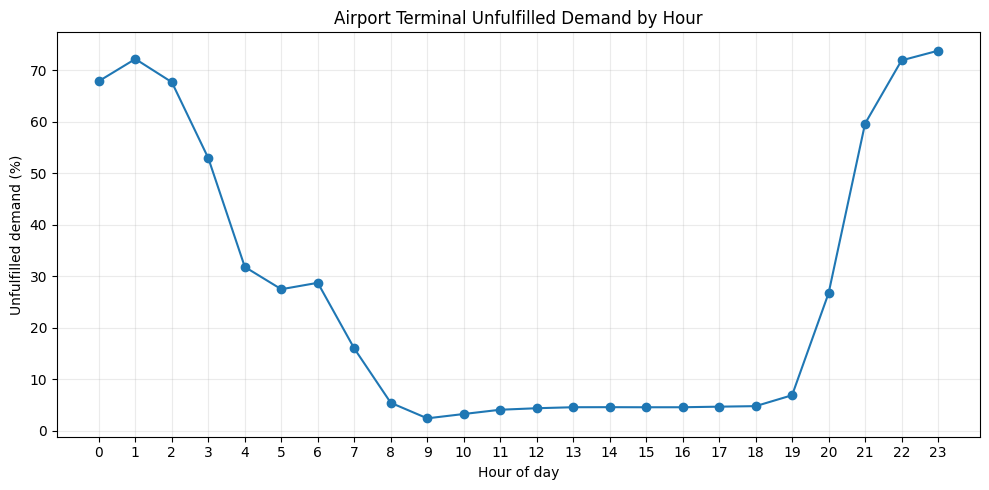

In [86]:
plt.figure(figsize=(10, 5))
plt.plot(
    hourly_plot["hour"],
    hourly_plot["unfulfilled_rate_pct"],
    marker="o",
)
plt.xlabel("Hour of day")
plt.ylabel("Unfulfilled demand (%)")
plt.title("Airport Terminal Unfulfilled Demand by Hour")
plt.xticks(range(24))
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 8. B2 - Post airport trip captain behavior

All records in `airport_trips` originate from airport terminals, so there is no non-airport pickup control group in this dataset. Instead, we compare destination types to understand how the airport trip ends may be associated with cancellation and the chance of a return fare within 20 minutes.

In [87]:
print("Unique pickup zones:", sorted(airport_trips["pickup_zone_id"].unique()))
print(
    "All trips airport-originating:",
    airport_trips["pickup_zone_id"].str.startswith("APT-").all()
)

Unique pickup zones: ['APT-T1', 'APT-T2']
All trips airport-originating: True


In [88]:
total_trips = len(airport_trips)
cancelled_trips = airport_trips["captain_cancelled"].sum()
return_fare_trips = airport_trips["got_return_fare_within_20min"].sum()

In [89]:
print(f"Airport trips: {total_trips:,}")
print(f"Captain-cancelled: {cancelled_trips:,} ({cancelled_trips / total_trips * 100:.1f}%)")
print(
    f"Return fare within 20 min: {return_fare_trips:,} "
    f"({return_fare_trips / total_trips * 100:.1f}%)"
)

Airport trips: 60,000
Captain-cancelled: 8,260 (13.8%)
Return fare within 20 min: 21,576 (36.0%)


In [90]:
trip_by_destination = (
    airport_trips
    .groupby("drop_zone_type")
    .agg(
        trips=("trip_id", "count"),
        cancelled_trips=("captain_cancelled", "sum"),
        return_fare_trips=("got_return_fare_within_20min", "sum"),
        avg_distance_km=("trip_distance_km", "mean"),
        avg_fare_inr=("fare_inr", "mean"),
    )
    .reset_index()
)

In [91]:
trip_by_destination["cancellation_rate_pct"] = (
    trip_by_destination["cancelled_trips"]
    / trip_by_destination["trips"]
    * 100
)

In [92]:
trip_by_destination["return_fare_rate_pct"] = (
    trip_by_destination["return_fare_trips"]
    / trip_by_destination["trips"]
    * 100
)

In [93]:
display(trip_by_destination)

,drop_zone_type,trips,cancelled_trips,return_fare_trips,avg_distance_km,avg_fare_inr,cancellation_rate_pct,return_fare_rate_pct
0,city_core,25282,2181,13329,13.237335,216.623092,8.626691,52.721304
1,suburban,24643,5176,4073,23.376524,353.565475,21.003936,16.528020
2,tech_park,10075,903,4174,16.104781,255.227792,8.962779,41.429280


### B2 interpretation

The destination split is descriptive. In particular, a low return-fare rate can indicate weaker immediate utilization after an airport trip, but the dataset does not establish that this causes cancellations or airport supply shortages.

In [94]:
display(
    trip_by_destination[
        [
            "drop_zone_type",
            "trips",
            "cancellation_rate_pct",
            "return_fare_rate_pct",
            "avg_distance_km",
            "avg_fare_inr",
        ]
    ].sort_values("return_fare_rate_pct")
)

,drop_zone_type,trips,cancellation_rate_pct,return_fare_rate_pct,avg_distance_km,avg_fare_inr
1,suburban,24643,21.003936,16.528020,23.376524,353.565475
2,tech_park,10075,8.962779,41.429280,16.104781,255.227792
0,city_core,25282,8.626691,52.721304,13.237335,216.623092


## 9. A3 - Evaluate `CAMP_WA_002`

The key question is whether the available data supports the campaign's claimed 5× scaling. The analysis first establishes campaign timing, then compares approval outcomes for a cohort with enough time for an 8-day exposure window.

Because campaign assignment was observational rather than randomized, the comparison is an estimate of association, not a causal experiment.

In [95]:
camp_wa_002 = nudges[
    nudges["campaign_id"] == "CAMP_WA_002"
].copy()

In [96]:
print(f"CAMP_WA_002 records: {len(camp_wa_002):,}")
print(f"Unique captains: {camp_wa_002['captain_id'].nunique():,}")

CAMP_WA_002 records: 8,673
Unique captains: 8,673


In [97]:
print("Channel:")
display(camp_wa_002["channel"].value_counts())

Channel:


channel
whatsapp    8673
Name: count, dtype: int64

In [98]:
print("Delivery:")
display(camp_wa_002["delivered"].value_counts(dropna=False))

Delivery:


delivered
1    8058
0     615
Name: count, dtype: int64

In [99]:
print("Clicks:")
display(camp_wa_002["clicked"].value_counts(dropna=False))

Clicks:


clicked
0    5104
1    3569
Name: count, dtype: int64

### Campaign timing relative to approval

In [100]:
campaign_timing = camp_wa_002.merge(
    captain_base[
        [
            "captain_id",
            "signup_ts",
            "decision_ts",
            "final_status",
            "eligible_for_funnel",
        ]
    ],
    on="captain_id",
    how="left",
    validate="one_to_one",
)

In [101]:
campaign_timing["hours_after_signup"] = (
    campaign_timing["sent_ts"] - campaign_timing["signup_ts"]
).dt.total_seconds() / 3600

In [102]:
campaign_timing["hours_before_decision"] = (
    campaign_timing["decision_ts"] - campaign_timing["sent_ts"]
).dt.total_seconds() / 3600

In [103]:
pre_decision_campaign = campaign_timing[
    campaign_timing["hours_before_decision"] > 0
].copy()

In [104]:
print(f"Sent before signup: {(campaign_timing['hours_after_signup'] < 0).sum():,}")
print(f"Sent after signup: {(campaign_timing['hours_after_signup'] >= 0).sum():,}")
print(f"Sent before approval decision: {len(pre_decision_campaign):,}")
print(f"Sent after/on decision: {(campaign_timing['hours_before_decision'] <= 0).sum():,}")

Sent before signup: 0
Sent after signup: 8,673
Sent before approval decision: 2,727
Sent after/on decision: 0


In [105]:
display(
    pre_decision_campaign["hours_after_signup"]
    .describe()
    .to_frame("hours_after_signup")
)

,hours_after_signup
count,2727.000000
mean,56.679044
std,20.710358
min,13.700235
25%,41.989234
50%,53.631199
75%,68.377675
max,184.939012


### 8 day exposure comparison cohort

We restrict to captains whose decision occurred at least 8 days after signup. This gives both exposed and unexposed captains the same 8-day opportunity window before the decision.

In [106]:
comparison = captain_base[
    captain_base["decision_ts"].notna()
    & (
        (
            captain_base["decision_ts"] - captain_base["signup_ts"]
        ).dt.total_seconds() / 86400 >= 8
    )
].copy()

In [107]:
campaign_8d = camp_wa_002.merge(
    captain_base[
        ["captain_id", "signup_ts", "decision_ts", "final_status"]
    ],
    on="captain_id",
    how="left",
    validate="one_to_one",
)

In [108]:
campaign_8d["days_after_signup"] = (
    campaign_8d["sent_ts"] - campaign_8d["signup_ts"]
).dt.total_seconds() / 86400

In [109]:
exposed_ids = set(
    campaign_8d.loc[
        campaign_8d["days_after_signup"].between(0, 8, inclusive="both"),
        "captain_id",
    ]
)

In [110]:
comparison["campaign_exposed"] = comparison["captain_id"].isin(exposed_ids)

In [111]:
print(f"Comparison cohort: {len(comparison):,}")
display(comparison["campaign_exposed"].value_counts())

Comparison cohort: 675


campaign_exposed
True     395
False    280
Name: count, dtype: int64

### Approval outcome

In [112]:
approval_comparison = (
    comparison
    .groupby("campaign_exposed")["final_status"]
    .agg(
        captains="size",
        approved=lambda x: (x == "approved").sum(),
    )
    .reset_index()
)

In [113]:
approval_comparison["approval_rate_pct"] = (
    approval_comparison["approved"]
    / approval_comparison["captains"]
    * 100
)

In [114]:
display(approval_comparison)

,campaign_exposed,captains,approved,approval_rate_pct
0,False,280,256,91.428571
1,True,395,358,90.632911


### Raw approval difference and confidence interval

In [115]:
treated = comparison[comparison["campaign_exposed"]]
control = comparison[~comparison["campaign_exposed"]]

In [116]:
p_treated = (treated["final_status"] == "approved").mean()
p_control = (control["final_status"] == "approved").mean()

In [117]:
n_treated = len(treated)
n_control = len(control)

In [118]:
diff = p_treated - p_control

In [119]:
se = math.sqrt(
    p_treated * (1 - p_treated) / n_treated
    + p_control * (1 - p_control) / n_control
)

In [120]:
ci_low = diff - 1.96 * se
ci_high = diff + 1.96 * se

In [121]:
print(f"Observed approval difference: {diff * 100:+.2f} pp")
print(f"95% CI: {ci_low * 100:+.2f} pp to {ci_high * 100:+.2f} pp")

Observed approval difference: -0.80 pp
95% CI: -5.16 pp to +3.56 pp


### Comparability check

We compare exposed and unexposed groups on city, acquisition channel, and device tier. Matching on overlapping strata is a diagnostic for imbalance; it does not turn the observational analysis into a randomized experiment.

In [122]:
for col in [
    "city",
    "vehicle_type",
    "acquisition_channel",
    "device_tier",
    "app_language",
    "age_band",
]:
    print(f"--- {col} ---")
    display(
        pd.crosstab(
            comparison[col],
            comparison["campaign_exposed"],
            normalize="columns",
        ).mul(100).round(2)
    )

--- city ---


campaign_exposed,False,True
city,,
Bangalore,24.29,23.29
Delhi,23.21,23.04
Hyderabad,33.57,30.38
Pune,18.93,23.29


--- vehicle_type ---


campaign_exposed,False,True
vehicle_type,,
Auto,50.36,50.63
Cab,39.64,38.99
ERickshaw,10.00,10.38


--- acquisition_channel ---


...

campaign_exposed,False,True
device_tier,,
high,15.00,15.95
low,40.36,44.05
mid,44.64,40.00


--- app_language ---


campaign_exposed,False,True
app_language,,
en,24.29,20.00
hi,19.29,16.96
kn,21.79,24.05
mr,16.07,19.75
te,18.57,19.24


--- age_band ---


campaign_exposed,False,True
age_band,,
18-24,19.64,20.76
25-34,41.07,42.78
35-44,26.43,27.34
45+,12.86,9.11


In [123]:
strata_cols = ["city", "acquisition_channel", "device_tier"]

In [124]:
overlap = (
    comparison
    .groupby(strata_cols)["campaign_exposed"]
    .nunique()
)

In [125]:
overlap_strata = overlap[overlap == 2].index

In [126]:
matched_population = (
    comparison
    .set_index(strata_cols)
    .loc[overlap_strata]
    .reset_index()
)

In [127]:
standardized = (
    matched_population
    .groupby("campaign_exposed")
    .agg(
        captains=("captain_id", "size"),
        approved=("final_status", lambda x: (x == "approved").sum()),
    )
)

In [128]:
standardized["approval_rate"] = (
    standardized["approved"] / standardized["captains"]
)

In [129]:
std_diff = (
    standardized.loc[True, "approval_rate"]
    - standardized.loc[False, "approval_rate"]
)

In [130]:
print(f"Total strata: {len(overlap):,}")
print(f"Strata with both groups: {(overlap == 2).sum():,}")
print(f"Strata with one group only: {(overlap == 1).sum():,}")
print(f"Captains in overlapping strata: {len(matched_population):,}")
print(f"Approval-rate difference in overlapping strata: {std_diff * 100:+.2f} pp")

Total strata: 59
Strata with both groups: 50
Strata with one group only: 9
Captains in overlapping strata: 652
Approval-rate difference in overlapping strata: +0.19 pp


In [131]:
display(standardized)

,captains,approved,approval_rate
campaign_exposed,,,
False,276,252,0.913043
True,376,344,0.914894


### Campaign exposure summary

In [132]:
print(f"Total CAMP_WA_002 recipients: {len(camp_wa_002):,}")
print(f"Pre-decision recipients: {len(pre_decision_campaign):,}")
print(
    f"Pre-decision share: "
    f"{len(pre_decision_campaign) / len(camp_wa_002) * 100:.1f}%"
)
print(
    f"Recipient share of all captains: "
    f"{len(camp_wa_002) / len(captain_base) * 100:.1f}%"
)

Total CAMP_WA_002 recipients: 8,673
Pre-decision recipients: 2,727
Pre-decision share: 31.4%
Recipient share of all captains: 34.7%


In [133]:
comparison["days_to_decision"] = (
    comparison["decision_ts"] - comparison["signup_ts"]
).dt.total_seconds() / 86400

display(
    comparison
    .groupby("campaign_exposed")["days_to_decision"]
    .agg(["count", "mean", "median"])
    .round(2)
)

,count,mean,median
campaign_exposed,,,
False,280,9.10,8.88
True,395,9.04,8.84


## 10. Key takeaways for the memo/deck

1. **A2O:** use the funnel table to identify the largest absolute captain-level leak and the corresponding stage conversion.
2. **Fixable leak:** use RC failure/recovery analysis to distinguish high-volume friction from a realistic intervention opportunity. The 10% RC recovery calculation is an illustrative scenario, not a forecast.
3. **Airport:** terminal demand pressure is concentrated at specific hours; destination-level trip behavior suggests that post-airport utilization differs materially by drop-zone type.
4. **Campaign:** `CAMP_WA_002` does not show a detectable approval lift in the available observational comparison. The confidence interval spans zero, so the evidence does **not** support a 5× scale-up.
5. **Next experiment:** if the campaign is strategically attractive, use a randomized holdout among eligible pre-decision captains and measure approval lift as the primary outcome.